2. Benchmark Source-of-Truth Inputs

This notebook does not manually rebuild the corridor from scratch.

Instead, it loads the shared benchmark inputs exported by Benchmark_calculation.ipynb.

The benchmark notebook provides:

- CTM cell order
- number of cells
- simulation timestep
- initial mainline vehicle states
- initial ramp queues
- boundary inflow series
- observed ramp release series
- ramp arrival series
- off-ramp flow series
- doorway capacity
- safe-threshold capacity
- physical capacity
- ramp maximum queue limits
- ramp name mapping
- free-flow travel time
- objective penalty weights
- benchmark totals
- benchmark normalization denominators

This keeps Greedy ADMM consistent with the official benchmark and ADMM-MPC notebooks.

3. CTM Corridor Structure

The freeway corridor is modeled using an 8-cell CTM.

Each cell stores the number of vehicles currently inside that freeway segment. At each 30-second timestep, the CTM updates the state using:

current cell states
boundary inflow
controlled ramp inflows
off-ramp flows
doorway capacities
physical capacities

The CTM update returns:

- next mainline vehicle states
- cell-to-cell outflows
- cell inflows
- actual off-ramp flows

The Greedy ADMM controller chooses ramp-release decisions, then the CTM determines how those ramp releases affect the freeway state.

4. Objective Function

The controller objective includes both freeway-side and ramp-side terms.

The main objective terms are:

Mainline delay:
Delay experienced by vehicles on the freeway mainline.

Local ramp delay:
Delay experienced by vehicles waiting in ramp queues.

Fairness penalty:
Penalty for imbalance across ramp queue stress levels.

Doorway penalty:
Penalty when attempted inflow exceeds doorway capacity.

Safe-threshold penalty:
Penalty when cell occupancy exceeds the safe operating threshold.

Physical-capacity penalty:
Penalty when cell occupancy exceeds physical storage capacity.

Spillback penalty:
Penalty when ramp queues exceed maximum ramp storage.

The raw objective is:

raw objective =
mainline delay
+ local delay
+ fairness penalty
+ doorway penalty
+ safe-threshold penalty
+ physical-capacity penalty
+ spillback penalty

However, these terms have very different numerical scales, so the controller also uses a normalized weighted objective.

5. Objective Normalization

Each objective term is normalized by its corresponding benchmark denominator.

For example:

normalized mainline delay = controller mainline delay / benchmark mainline delay

normalized local delay = controller local delay / benchmark local delay

normalized safe penalty = controller safe penalty / benchmark safe penalty

The normalized weighted objective is:

J =
alpha_main * normalized_mainline_delay
+ beta_local * normalized_local_delay
+ normalized_fairness_penalty
+ normalized_doorway_penalty
+ normalized_safe_penalty
+ normalized_physical_penalty
+ normalized_spillback_penalty

In this notebook:

alpha_main = 30.0
beta_local = 1.0

The benchmark normalized objective equals:

34.000

because the benchmark is compared against its own normalization denominators.

6. Greedy ADMM Controller

The Greedy ADMM controller solves one control problem per 30-second timestep.

At each timestep, the controller chooses ramp releases for the controlled ramps:

u1, u2, u3, u4, u5

The controller decomposes the problem into two ADMM blocks:

1. Ramp-side block
2. Freeway-side block

The ramp-side block focuses on:

- ramp queue updates
- local ramp delay
- fairness penalty
- spillback penalty

The freeway-side block focuses on:

- CTM state update
- mainline delay
- doorway penalty
- safe-threshold penalty
- physical-capacity penalty

ADMM forces the ramp-side decision u and freeway-side decision z to agree.

The ADMM loop follows:

1. Solve ramp-side update
2. Solve freeway-side update
3. Update dual variables
4. Compute primal residual
5. Compute dual residual
6. Stop when convergence conditions are satisfied
7. Difference Between Greedy ADMM and ADMM-MPC

Greedy ADMM and ADMM-MPC use the same CTM dynamics and many of the same objective terms, but they are not the same controller.

The difference is:

Greedy ADMM:
Optimizes only the current 30-second timestep.

ADMM-MPC:
Optimizes over a future rolling horizon.

This means Greedy ADMM has no lookahead. It cannot anticipate future congestion, future ramp arrivals, or future spillback pressure.

ADMM-MPC can make better decisions because it considers how the current ramp release affects future freeway states and future ramp queues.

8. One-Step Greedy ADMM Test

Before running the full one-hour simulation, this notebook tests the Greedy ADMM solver on the first 30-second timestep.

This verifies that:

- ramp-release bounds are valid
- ramp queues update correctly
- CTM state updates correctly
- spillback is computed correctly
- mainline delay is computed correctly
- local delay is computed correctly
- objective terms are returned correctly
- ADMM residuals are tracked correctly

The one-step test is only a debugging and verification step.

The final reported results come from the full 120-step simulation.

9. Full 120-Step Simulation

The official simulation uses 120 timesteps.

Since each timestep is 30 seconds:

120 steps × 30 seconds = 3600 seconds = 1 hour

At every timestep, the controller uses the benchmark-loaded time-varying inputs:

observed_release_series
ramp_arrival_series
q_in_boundary_series
f_out_series

For each timestep:

1. Load current ramp arrivals.
2. Load current observed ramp releases.
3. Load current boundary inflow.
4. Load current off-ramp flows.
5. Build ramp meter-capacity limits.
6. Solve one Greedy ADMM control problem.
7. Apply the optimized ramp releases.
8. Update the CTM mainline state.
9. Update ramp queues.
10. Move to the next timestep.

This produces a complete one-hour Greedy ADMM-controlled trajectory.

10. ADMM Convergence

The Greedy ADMM simulation tracks convergence using:

primal residual
dual residual
number of ADMM iterations

The official convergence settings used for the fair comparison are:

min_admm_iters = 20
max_admm_iters = 150
tol_primal = 1e-3
tol_dual = 1e-2

A sensitivity experiment also tests larger fixed minimum iteration counts.

The key convergence check is:

Steps above tolerance = 0 out of 120

This confirms that the ADMM solver successfully satisfies the residual tolerances across the full one-hour simulation.

11. Official Greedy ADMM Result

The best tested Greedy ADMM setting is:

meter_multiplier = 1.0
min_admm_iters = 150
max_admm_iters = 150

This setting keeps ramp meter capacity equal to the observed-release metering level and allows the ADMM solver to refine the one-step solution more strongly.

The official benchmark result is:

Benchmark normalized objective = 34.000
Benchmark total system delay = 88,074.345 veh-min

The best Greedy ADMM result is:

Greedy ADMM normalized objective = 32.205923
Greedy ADMM total system delay = 85,688.209 veh-min

The improvement is:

Normalized objective change = -5.277%
Total system delay change = -2.709%

This means Greedy ADMM improves over the observed-release benchmark, but the improvement is moderate.

12. Benchmark vs Greedy ADMM Interpretation

The Greedy ADMM controller reduces the normalized objective and total system delay compared with the benchmark.

However, the improvement is much smaller than the improvement obtained by ADMM-MPC.

This supports the main modeling conclusion:

One-step ADMM improves the benchmark modestly.
Rolling-horizon ADMM-MPC improves the benchmark much more.

The reason is that Greedy ADMM only reacts to the current timestep. It does not plan ahead.

ADMM-MPC uses a prediction horizon, so it can account for future freeway congestion and future ramp queue pressure.

Therefore, the larger ADMM-MPC improvement comes mainly from MPC lookahead, not merely from using ADMM.

13. Final State and Queue Diagnostics

The notebook also prints final system diagnostics after the one-hour simulation.

These include:

- final optimized ramp releases
- final mainline vehicle states
- final ramp queues
- final spillback values
- maximum cell occupancy
- maximum ramp queue
- maximum spillback
- average Greedy ADMM ramp release
- average observed ramp release

These diagnostics are important because they check whether the controller produces realistic traffic behavior.

They help verify that:

- mainline states remain physically meaningful
- ramp queues update consistently
- spillback is explicitly measured
- vehicles are not silently lost
- ramp releases stay within the chosen metering limits
14. Visualization

The notebook generates benchmark-vs-Greedy ADMM plots for:

- mainline delay
- local ramp delay
- fairness penalty
- doorway penalty
- safe-threshold penalty
- spillback penalty
- capacity penalty
- normalized weighted objective

The visualizations show which objective terms improve and which terms worsen under Greedy ADMM control.

Because the safe-threshold penalty is much larger than the smaller delay and fairness terms, the plots separate smaller-scale and larger-scale terms for readability.

15. Sensitivity Experiment

The notebook also runs a sensitivity experiment over:

meter-capacity multiplier
ADMM minimum iteration count

The meter-capacity rule is:

meter_capacity = meter_multiplier × observed_release

The tested meter multipliers are:

1.0, 1.1, 1.2, 1.5, 2.0

The tested ADMM iteration settings include:

20, 50, 100, 150 minimum iterations

The sensitivity experiment shows two important patterns.

First, increasing the ADMM minimum iteration count improves the Greedy ADMM solution when the meter multiplier is 1.0.

For meter multiplier 1.0:

20 iterations:
objective = 33.586003
objective change = -1.218%
delay change = -0.566%

50 iterations:
objective = 33.129079
objective change = -2.562%
delay change = -1.219%

100 iterations:
objective = 32.577984
objective change = -4.182%
delay change = -2.088%

150 iterations:
objective = 32.205923
objective change = -5.277%
delay change = -2.709%

Second, increasing the meter-capacity multiplier above 1.0 makes the result worse.

For example:

meter multiplier = 1.1:
best objective change = +7.212%

meter multiplier = 1.2:
best objective change = +19.696%

meter multiplier = 1.5:
best objective change = +59.181%

meter multiplier = 2.0:
best objective change = +59.181%

This means allowing more ramp release does not improve the system. It overloads the freeway mainline, increases mainline delay, and increases safe-threshold penalties.

The sensitivity experiment shows that the corridor bottleneck is the freeway mainline, not insufficient ramp discharge capacity.

16. Final Conclusion

The fixed Greedy ADMM notebook now provides a clean second model for the project.

The final result shows:

Benchmark normalized objective = 34.000
Greedy ADMM normalized objective = 32.205923
Objective improvement = 5.277%

Benchmark system delay = 88,074.345 veh-min
Greedy ADMM system delay = 85,688.209 veh-min
System delay improvement = 2.709%

Greedy ADMM improves over the observed-release benchmark, but the improvement is modest.

This is expected because Greedy ADMM is a one-step controller with no prediction horizon.

The stronger ADMM-MPC result should be interpreted as the benefit of adding rolling-horizon lookahead to the ADMM-based traffic control framework.

The final project story is:

Observed benchmark:
baseline field-style release behavior

Greedy ADMM:
one-step optimization, modest improvement

ADMM-MPC:
rolling-horizon optimization, strong improvement

Therefore, Greedy ADMM is useful not because it beats ADMM-MPC, but because it proves that lookahead matters.

The sensitivity experiment also confirms that simply allowing larger ramp releases is not the solution. Higher meter-capacity multipliers worsen freeway congestion and increase safe-threshold penalties.

The best tested Greedy ADMM configuration keeps:

meter_multiplier = 1.0
min_admm_iters = 150
max_admm_iters = 150

This gives the strongest Greedy ADMM result while keeping the ramp-metering capacity consistent with the observed-release benchmark.

In [1]:
%run Benchmark_calculation.ipynb
import pandas as pd

Selected Station Metadata 
Number of selected stations: 15


,station_id,station_name,station_type,freeway,direction,absolute_postmile,length,lanes,latitude,longitude
0,1201419,RED HILL,ML,405,S,8.17,0.269,5,33.686517,-117.866474
1,1201465,BRISTOL 1,FR,405,S,9.31,NaN,2,33.687251,-117.886180
2,1201469,BRISTOL 1,ML,405,S,9.31,0.350,5,33.687251,-117.886180
3,1201460,BRISTOL 1,OR,405,S,9.31,NaN,1,33.687251,-117.886180
4,1201497,FAIRVIEW,ML,405,S,10.05,0.460,5,33.687480,-117.899035
5,1201490,FAIRVIEW,OR,405,S,10.07,NaN,1,33.687494,-117.899383
6,1201525,HARBOR 1,ML,405,S,10.97,0.610,6,33.687942,-117.915002
7,1201517,HARBOR 1,OR,405,S,10.97,NaN,1,33.687942,-117.915002
8,1201554,HARBOR 2,FR,405,S,11.27,NaN,3,33.689212,-117.919950
9,1201558,HARBOR 2,ML,405,S,11.27,0.480,5,33.689212,-117.919950


Midnight / Free-Flow Window Data 
Time window: 2026-01-08 01:00:00 to 2026-01-08 05:00:00
Rows: 720
Unique timestamps: 48
Unique stations: 15

First 20 rows:


,timestamp,station_id,station_type,total_flow,avg_occupancy,avg_speed
0,2026-01-08 01:00:00,1201419,ML,112.0,0.0345,47.3
1,2026-01-08 01:00:00,1201460,OR,0.0,0.0000,NaN
2,2026-01-08 01:00:00,1201465,FR,NaN,NaN,NaN
3,2026-01-08 01:00:00,1201469,ML,112.0,0.0257,61.4
4,2026-01-08 01:00:00,1201490,OR,9.0,0.0200,NaN
5,2026-01-08 01:00:00,1201497,ML,55.0,0.0049,69.8
6,2026-01-08 01:00:00,1201517,OR,3.0,0.0030,NaN
7,2026-01-08 01:00:00,1201525,ML,54.0,0.0097,64.5
8,2026-01-08 01:00:00,1201548,OR,6.0,0.0110,NaN
9,2026-01-08 01:00:00,1201554,FR,10.0,0.0033,NaN



Rows for station 1201419 (RED HILL):


...

Problem 20: Soft-Capacity Diagnostic for On-Ramp Inflow
Number of soft-capacity violation rows: 398
NOTE: capacity violations occurred and were handled through soft penalties.


,step,cell,q_in,u_in,total_inflow,doorway_capacity,doorway_overflow,x_next,safe_threshold_capacity,safe_overflow,physical_capacity,physical_overflow
0,1,Cell 2,84.327,8.8,93.127,84.327,8.8,133.000,413.744,0.000,591.062,0.0
1,1,Cell 4,84.327,3.9,88.227,84.327,3.9,101.572,413.744,0.000,591.062,0.0
2,1,Cell 6,84.327,5.6,89.927,84.327,5.6,173.859,413.744,0.000,591.062,0.0
3,2,Cell 2,84.327,8.8,93.127,84.327,8.8,141.800,413.744,0.000,591.062,0.0
4,2,Cell 4,84.327,3.9,88.227,84.327,3.9,105.472,413.744,0.000,591.062,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
393,119,Cell 7,78.327,7.6,85.927,101.192,0.0,630.948,496.492,134.456,709.275,0.0
394,120,Cell 4,70.727,5.4,76.127,84.327,0.0,520.336,413.744,106.592,591.062,0.0
395,120,Cell 5,76.127,8.2,84.327,101.192,0.0,633.148,496.492,136.656,709.275,0.0
396,120,Cell 6,84.327,5.8,90.127,84.327,5.8,341.895,413.744,0.000,591.062,0.0


Soft-capacity violation summary by cell


,cell,violation_steps,max_doorway_overflow,max_safe_overflow,max_physical_overflow
0,Cell 2,23,8.8,0.000,0.0
1,Cell 4,98,5.1,106.992,0.0
2,Cell 5,83,0.0,138.156,0.0
3,Cell 6,120,8.2,0.000,0.0
4,Cell 7,74,0.0,135.756,0.0


Problem 19: Conservative Off-Ramp Outflow Diagnostic
Total capped off-ramp events: 0
Max requested-minus-actual off-ramp gap: 0.0
PASS: no off-ramp over-drain occurred in the benchmark run.


In [2]:
# Load shared benchmark inputs exported by Benchmark_calculation.ipynb

shared_inputs_path = "shared_benchmark_inputs.pkl"

if not os.path.exists(shared_inputs_path):
    raise FileNotFoundError(
        "shared_benchmark_inputs.pkl was not found. "
        "Run Benchmark_calculation.ipynb first and make sure the export cell completed."
    )

with open(shared_inputs_path, "rb") as file:
    shared_benchmark_inputs = pickle.load(file)

official_totals = shared_benchmark_inputs["official_totals"]
benchmark_denominators = shared_benchmark_inputs["benchmark_denominators"]

print("Loaded shared benchmark inputs.")
print("Benchmark mainline delay:", round(official_totals["mainline_delay"], 3))
print("Benchmark local delay:", round(official_totals["local_delay"], 3))
print("Benchmark raw objective:", round(official_totals["raw_objective"], 3))

Loaded shared benchmark inputs.
Benchmark mainline delay: 72848.691
Benchmark local delay: 15225.654
Benchmark raw objective: 1507761.479


In [3]:
# Corridor and CTM constants
segment_start_PM = 8.17
segment_end_PM = 13.07

cell_length_mile_display = (
    segment_end_PM - segment_start_PM
) / num_cells

print("Number of CTM cells:", num_cells)
print("Cell length:", round(cell_length_mile_display, 4), "mile")
print("Simulation timestep:", delta_t, "min")
print("Jam density:", jam_density, "veh/mi/lane")

Number of CTM cells: 8
Cell length: 0.6125 mile
Simulation timestep: 0.5 min
Jam density: 193 veh/mi/lane


In [4]:
# Corridor structure loaded from Benchmark_calculation.ipynb

print("CTM cells:")
print(cell_order)

print("\nRamp IDs:")
print(ramp_ids)

print("\nRamp name map:")
for ramp_id, ramp_name in ramp_name_map.items():
    print(ramp_id, "->", ramp_name)

CTM cells:
['Cell 1', 'Cell 2', 'Cell 3', 'Cell 4', 'Cell 5', 'Cell 6', 'Cell 7', 'Cell 8']

Ramp IDs:
['u1', 'u2', 'u3', 'u4', 'u5']

Ramp name map:
u1 -> Bristol 1
u2 -> Fairview
u3 -> Harbor 1
u4 -> Harbor 2
u5 -> Euclid


In [5]:
# Capacity variables loaded from Benchmark_calculation.ipynb

print("Cell lane count:")
for i, cell in enumerate(cell_order, start=1):
    print(cell, ":", cell_lane_count[i])

print("\nDoorway capacity:")
for cell in cell_order:
    print(cell, ":", round(doorway_capacity[cell], 3))

print("\nSafe-threshold capacity:")
for cell in cell_order:
    print(cell, ":", round(safe_threshold_capacity[cell], 3))

print("\nPhysical capacity:")
for cell in cell_order:
    print(cell, ":", round(physical_capacity[cell], 3))

Cell lane count:
Cell 1 : 5
Cell 2 : 5
Cell 3 : 5
Cell 4 : 5
Cell 5 : 6
Cell 6 : 5
Cell 7 : 6
Cell 8 : 5

Doorway capacity:
Cell 1 : 84.327
Cell 2 : 84.327
Cell 3 : 84.327
Cell 4 : 84.327
Cell 5 : 101.192
Cell 6 : 84.327
Cell 7 : 101.192
Cell 8 : 84.327

Safe-threshold capacity:
Cell 1 : 413.744
Cell 2 : 413.744
Cell 3 : 413.744
Cell 4 : 413.744
Cell 5 : 496.493
Cell 6 : 413.744
Cell 7 : 496.493
Cell 8 : 413.744

Physical capacity:
Cell 1 : 591.062
Cell 2 : 591.062
Cell 3 : 591.062
Cell 4 : 591.062
Cell 5 : 709.275
Cell 6 : 591.062
Cell 7 : 709.275
Cell 8 : 591.062


In [6]:

# CTM cell table from benchmark-loaded variables

cell_rows = []

for i, cell in enumerate(cell_order, start=1):
    cell_rows.append({
        "Cell": cell,
        "Lane count": cell_lane_count[i],
        "Doorway capacity": doorway_capacity[cell],
        "Safe-threshold capacity": safe_threshold_capacity[cell],
        "Physical capacity": physical_capacity[cell],
    })

cell_table = pd.DataFrame(cell_rows)

display(
    cell_table.round({
        "Doorway capacity": 3,
        "Safe-threshold capacity": 3,
        "Physical capacity": 3,
    })
)

,Cell,Lane count,Doorway capacity,Safe-threshold capacity,Physical capacity
0,Cell 1,5,84.327,413.744,591.062
1,Cell 2,5,84.327,413.744,591.062
2,Cell 3,5,84.327,413.744,591.062
3,Cell 4,5,84.327,413.744,591.062
4,Cell 5,6,101.192,496.492,709.275
5,Cell 6,5,84.327,413.744,591.062
6,Cell 7,6,101.192,496.492,709.275
7,Cell 8,5,84.327,413.744,591.062


In [7]:
# Benchmark-loaded simulation mappings
print("CTM cell order:")
print(cell_order)

print("\nControlled ramp IDs:")
print(ramp_ids)

print("\nRamp-to-name mapping:")
for ramp_id in ramp_ids:
    print(ramp_id, "->", ramp_name_map[ramp_id])

print("\nAvailable time steps:")
print("q_in_boundary_series:", len(q_in_boundary_series))
print("observed_release_series:", len(observed_release_series[ramp_ids[0]]))
print("ramp_arrival_series:", len(ramp_arrival_series[ramp_ids[0]]))
print("f_out_series:", len(f_out_series))

print("\nFirst f_out_series entry:")
print(f_out_series[0])

CTM cell order:
['Cell 1', 'Cell 2', 'Cell 3', 'Cell 4', 'Cell 5', 'Cell 6', 'Cell 7', 'Cell 8']

Controlled ramp IDs:
['u1', 'u2', 'u3', 'u4', 'u5']

Ramp-to-name mapping:
u1 -> Bristol 1
u2 -> Fairview
u3 -> Harbor 1
u4 -> Harbor 2
u5 -> Euclid

Available time steps:
q_in_boundary_series: 120
observed_release_series: 120
ramp_arrival_series: 120
f_out_series: 120

First f_out_series entry:
{'Cell 1': 0.0, 'Cell 2': 0.0, 'Cell 3': 0.0, 'Cell 4': 0.0, 'Cell 5': 0.0, 'Cell 6': 8.2, 'Cell 7': 0.8, 'Cell 8': 0.0}


In [8]:
# Initial mainline state loaded from Benchmark_calculation.ipynb
x_current = mainline_initial_state.copy()

print("Initial mainline state:")
for cell in cell_order:
    print(cell, ":", round(x_current[cell], 3))

Initial mainline state:
Cell 1 : 121.616
Cell 2 : 124.2
Cell 3 : 93.752
Cell 4 : 97.672
Cell 5 : 171.734
Cell 6 : 176.459
Cell 7 : 216.385
Cell 8 : 159.833


# ADMM Implementation




In [9]:
from scipy.optimize import minimize
import numpy as np

def build_uin(u_dict):
    return {
        "Cell 1": 0.0,
        "Cell 2": float(u_dict["u1"]),
        "Cell 3": 0.0,
        "Cell 4": float(u_dict["u2"]),
        "Cell 5": float(u_dict["u3"]),
        "Cell 6": float(u_dict["u4"]),
        "Cell 7": float(u_dict["u5"]),
        "Cell 8": 0.0,
    }

In [10]:
# Ramp-side objective block for Greedy ADMM

def ramp_block_objective(
    u_dict,
    ramp_queue_now,
    ramp_arrival,
    ramp_name_map,
    ramp_max_queue_named,
    gamma,
    lambda_4,
    delta_t,
    benchmark_denominators,
    beta_local,
):
    ramp_next = {}
    spillback_by_ramp = {}

    # Ramp queue update
    for ramp in u_dict:
        R_now = float(ramp_queue_now[ramp])
        a_now = float(ramp_arrival[ramp])
        u_now = float(u_dict[ramp])

        ramp_name = ramp_name_map[ramp]
        R_max = float(ramp_max_queue_named[ramp_name])

        R_raw = R_now + a_now - u_now

        R_next = min(R_raw, R_max)
        spillback = max(0.0, R_raw - R_max)

        ramp_next[ramp] = R_next
        spillback_by_ramp[ramp] = spillback

    # Local ramp delay
    total_local_delay = 0.0

    for ramp in ramp_queue_now:
        R_now = float(ramp_queue_now[ramp])
        R_next = float(ramp_next[ramp])

        D_local = ((R_now + R_next) / 2.0) * delta_t
        total_local_delay += D_local

    # Queue-stress fairness penalty
    stress_capped = {}

    for ramp in ramp_next:
        ramp_name = ramp_name_map[ramp]
        R_max = float(ramp_max_queue_named[ramp_name])

        raw_stress = ramp_next[ramp] / R_max
        stress_capped[ramp] = min(raw_stress, 1.0)

    ramps = list(stress_capped.keys())

    fairness_raw = 0.0

    for i in range(len(ramps)):
        for j in range(i + 1, len(ramps)):
            phi_i = stress_capped[ramps[i]]
            phi_j = stress_capped[ramps[j]]
            fairness_raw += (phi_i - phi_j) ** 2

    fairness_penalty = gamma * fairness_raw

    # Spillback penalty
    spillback_raw = 0.0

    for ramp in spillback_by_ramp:
        spillback_raw += spillback_by_ramp[ramp] ** 2

    spillback_penalty = lambda_4 * spillback_raw

    # Normalized ramp-side objective

    local_delay_norm = (
        total_local_delay
        / benchmark_denominators["local_delay"]
    )

    fairness_norm = (
        fairness_penalty
        / benchmark_denominators["fairness_penalty"]
    )

    spillback_norm = (
        spillback_penalty
        / benchmark_denominators["spillback_penalty"]
    )

    total_ramp_obj = (
        beta_local * local_delay_norm
        + fairness_norm
        + spillback_norm
    )

    return (
        total_ramp_obj,
        ramp_next,
        spillback_by_ramp,
        total_local_delay,
        fairness_penalty,
        spillback_penalty,
    )

In [11]:
# Freeway-side objective block for Greedy ADMM
def freeway_block_objective(
    z_dict,
    current_mainline_state,
    q_in_boundary,
    f_out_requested,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    delta_t,
    lambda_1,
    lambda_2,
    lambda_3,
    benchmark_denominators,
    alpha_main,
):
    # Convert ramp releases to cell-based on-ramp inflows
    u_in = build_uin(z_dict)

    # CTM update
    x_next, q_out, q_in, sending, receiving, actual_f_out = ctm_30sec_step(
        current_mainline_state,
        q_in_boundary,
        u_in,
        f_out_requested,
        doorway_capacity,
        physical_capacity,
    )

    # Mainline delay
    _, total_mainline_delay = mainline_delay_one_step(
        current_mainline_state,
        x_next,
        q_out,
        actual_f_out,
        tt_ff_min,
        delta_t,
    )

    # Doorway overflow penalty
    doorway_raw = 0.0

    for cell in q_in:
        overflow = max(
            0.0,
            q_in[cell] + u_in[cell] - doorway_capacity[cell]
        )
        doorway_raw += overflow ** 2

    doorway_penalty = lambda_1 * doorway_raw

    # Safe-threshold penalty
    safe_raw = 0.0

    for cell in x_next:
        overflow = max(
            0.0,
            x_next[cell] - safe_threshold_capacity[cell]
        )
        safe_raw += overflow ** 2

    safe_penalty = lambda_2 * safe_raw

    # Physical-capacity penalty
    physical_raw = 0.0

    for cell in x_next:
        overflow = max(
            0.0,
            x_next[cell] - physical_capacity[cell]
        )
        physical_raw += overflow ** 2

    physical_penalty = lambda_3 * physical_raw

    # Normalized freeway-side objective

    mainline_delay_norm = (
        total_mainline_delay
        / benchmark_denominators["mainline_delay"]
    )

    doorway_norm = (
        doorway_penalty
        / benchmark_denominators["doorway_penalty"]
    )

    safe_norm = (
        safe_penalty
        / benchmark_denominators["safe_penalty"]
    )

    physical_denominator = benchmark_denominators["physical_penalty"]

    if physical_denominator == 0:
        physical_norm = 0.0 if physical_penalty == 0 else physical_penalty
    else:
        physical_norm = physical_penalty / physical_denominator

    total_freeway_obj = (
        alpha_main * mainline_delay_norm
        + doorway_norm
        + safe_norm
        + physical_norm
    )

    return (
        total_freeway_obj,
        x_next,
        q_out,
        q_in,
        actual_f_out,
        total_mainline_delay,
        doorway_penalty,
        safe_penalty,
        physical_penalty,
    )

In [12]:

# ADMM helper functions
def get_u_bounds(
    ramp_queue_now,
    ramp_arrival,
    meter_capacity,
    ramp_name_map,
    ramp_max_queue_named,
):
    lower_bounds = {}
    upper_bounds = {}

    for ramp in ramp_queue_now:
        R_now = float(ramp_queue_now[ramp])
        a_now = float(ramp_arrival[ramp])

        # Maximum release:
        # cannot release more than available vehicles
        # and cannot exceed meter capacity.
        u_max = min(
            R_now + a_now,
            float(meter_capacity[ramp])
        )

        ramp_name = ramp_name_map[ramp]
        R_max = float(ramp_max_queue_named[ramp_name])

        # Minimum release needed to avoid spillback.
        # If this exceeds u_max, cap it at u_max because the controller
        # cannot release more vehicles than are available or physically allowed.
        u_min_spill = max(
            0.0,
            R_now + a_now - R_max
        )

        u_min = min(u_min_spill, u_max)

        lower_bounds[ramp] = u_min
        upper_bounds[ramp] = u_max

    return lower_bounds, upper_bounds


def dual_update(y, u, z):
    y_next = {}

    for ramp in y:
        y_next[ramp] = y[ramp] + (u[ramp] - z[ramp])

    return y_next


def primal_residual(u, z):
    total = 0.0

    for ramp in u:
        total += (u[ramp] - z[ramp]) ** 2

    return total ** 0.5


def dual_residual(z, z_prev, rho):
    total = 0.0

    for ramp in z:
        total += (rho * (z[ramp] - z_prev[ramp])) ** 2

    return total ** 0.5

In [13]:
# Local ADMM update: ramp-side subproblem
def local_admm_update(
    u_init,
    z,
    y,
    ramp_queue_now,
    ramp_arrival,
    ramp_name_map,
    ramp_max_queue_named,
    gamma,
    lambda_4,
    delta_t,
    rho,
    lower_bounds,
    upper_bounds,
    benchmark_denominators,
    beta_local,
):
    ramps = list(u_init.keys())

    x0 = np.array([
        float(u_init[ramp])
        for ramp in ramps
    ])

    z_arr = np.array([
        float(z[ramp])
        for ramp in ramps
    ])

    y_arr = np.array([
        float(y[ramp])
        for ramp in ramps
    ])

    bounds_arr = [
        (float(lower_bounds[ramp]), float(upper_bounds[ramp]))
        for ramp in ramps
    ]

    def objective_u(x):
        u_dict = {
            ramps[i]: float(x[i])
            for i in range(len(ramps))
        }

        base_obj, _, _, _, _, _ = ramp_block_objective(
            u_dict=u_dict,
            ramp_queue_now=ramp_queue_now,
            ramp_arrival=ramp_arrival,
            ramp_name_map=ramp_name_map,
            ramp_max_queue_named=ramp_max_queue_named,
            gamma=gamma,
            lambda_4=lambda_4,
            delta_t=delta_t,
            benchmark_denominators=benchmark_denominators,
            beta_local=beta_local,
        )

        admm_penalty = (rho / 2.0) * np.sum(
            (x - z_arr + y_arr) ** 2
        )

        return base_obj + admm_penalty

    result = minimize(
        objective_u,
        x0,
        method="SLSQP",
        bounds=bounds_arr,
    )

    if not result.success:
        print("WARNING: local_admm_update SLSQP did not fully converge.")
        print("Message:", result.message)

    u_opt = {
        ramps[i]: float(result.x[i])
        for i in range(len(ramps))
    }

    return u_opt

In [14]:

# Global ADMM update: freeway-side subproblem
def global_admm_update(
    z_init,
    u,
    y,
    current_mainline_state,
    q_in_boundary,
    f_out_requested,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    delta_t,
    lambda_1,
    lambda_2,
    lambda_3,
    rho,
    lower_bounds,
    upper_bounds,
    benchmark_denominators,
    alpha_main,
):
    ramps = list(z_init.keys())

    x0 = np.array([
        float(z_init[ramp])
        for ramp in ramps
    ])

    u_arr = np.array([
        float(u[ramp])
        for ramp in ramps
    ])

    y_arr = np.array([
        float(y[ramp])
        for ramp in ramps
    ])

    bounds_arr = [
        (float(lower_bounds[ramp]), float(upper_bounds[ramp]))
        for ramp in ramps
    ]

    def objective_z(x):
        z_dict = {
            ramps[i]: float(x[i])
            for i in range(len(ramps))
        }

        (
            base_obj,
            _,
            _,
            _,
            _,
            _,
            _,
            _,
            _,
        ) = freeway_block_objective(
            z_dict=z_dict,
            current_mainline_state=current_mainline_state,
            q_in_boundary=q_in_boundary,
            f_out_requested=f_out_requested,
            doorway_capacity=doorway_capacity,
            physical_capacity=physical_capacity,
            safe_threshold_capacity=safe_threshold_capacity,
            tt_ff_min=tt_ff_min,
            delta_t=delta_t,
            lambda_1=lambda_1,
            lambda_2=lambda_2,
            lambda_3=lambda_3,
            benchmark_denominators=benchmark_denominators,
            alpha_main=alpha_main,
        )

        admm_penalty = (rho / 2.0) * np.sum(
            (x - u_arr - y_arr) ** 2
        )

        return base_obj + admm_penalty

    result = minimize(
        objective_z,
        x0,
        method="SLSQP",
        bounds=bounds_arr,
    )

    if not result.success:
        print("WARNING: global_admm_update SLSQP did not fully converge.")
        print("Message:", result.message)

    z_opt = {
        ramps[i]: float(result.x[i])
        for i in range(len(ramps))
    }

    return z_opt

In [15]:

# Ramp meter capacity

observed_release = {
    ramp: float(observed_release_series[ramp][0])
    for ramp in ramp_ids
}

meter_capacity = {
    ramp: 1.0 * observed_release[ramp]
    for ramp in ramp_ids
}

print("Ramp meter capacity:")
for ramp in ramp_ids:
    print(ramp, ":", round(meter_capacity[ramp], 3))

Ramp meter capacity:
u1 : 8.8
u2 : 3.9
u3 : 7.3
u4 : 5.6
u5 : 6.4


In [16]:
# Greedy ADMM global configuration

num_steps = shared_benchmark_inputs["num_steps"]
delta_t = shared_benchmark_inputs["delta_t"]

# Penalty weights loaded from benchmark/source-of-truth object.
gamma = shared_benchmark_inputs["gamma"]
lambda_1 = shared_benchmark_inputs["lambda_1"]
lambda_2 = shared_benchmark_inputs["lambda_2"]
lambda_3 = shared_benchmark_inputs["lambda_3"]
lambda_4 = shared_benchmark_inputs["lambda_4"]

# Controller tradeoff weights.
# These must match ADMM-MPC.
alpha_main = 30.0
beta_local = 1.0

objective_weights = {
    "alpha_main": alpha_main,
    "beta_local": beta_local,
    "gamma": gamma,
    "lambda_1": lambda_1,
    "lambda_2": lambda_2,
    "lambda_3": lambda_3,
    "lambda_4": lambda_4,
}

print("Greedy ADMM configuration:")
print("num_steps =", num_steps)
print("delta_t =", delta_t)

print("\nGreedy ADMM objective weights:")
for name, value in objective_weights.items():
    print(f"{name} = {value}")

Greedy ADMM configuration:
num_steps = 120
delta_t = 0.5

Greedy ADMM objective weights:
alpha_main = 30.0
beta_local = 1.0
gamma = 1
lambda_1 = 1.0
lambda_2 = 0.5
lambda_3 = 1.0
lambda_4 = 0.5


In [17]:

# Standardize benchmark denominator names
benchmark_denominators_clean = {
    "mainline_delay": benchmark_denominators["D_main_base"],
    "local_delay": benchmark_denominators["D_local_base"],
    "fairness_penalty": benchmark_denominators["L_fair_base"],
    "doorway_penalty": benchmark_denominators["P_door_base"],
    "safe_penalty": benchmark_denominators["P_safe_base"],
    "physical_penalty": benchmark_denominators["P_phys_base"],
    "spillback_penalty": benchmark_denominators["P_spill_base"],
}

print("Clean benchmark denominators:")
for key, value in benchmark_denominators_clean.items():
    print(key, "=", round(value, 6))

Clean benchmark denominators:
mainline_delay = 72848.691296
local_delay = 15225.6536
fairness_penalty = 25.452969
doorway_penalty = 5712.107584
safe_penalty = 2820990.743053
physical_penalty = 1.0
spillback_penalty = 6908.404057


In [18]:
# One-step Greedy ADMM solver

def solve_one_step_admm(
    current_mainline_state,
    ramp_queue_now,
    ramp_arrival,
    observed_release,
    meter_capacity,
    q_in_boundary,
    f_out_requested,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    ramp_name_map,
    ramp_max_queue_named,
    delta_t,
    gamma,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4,
    benchmark_denominators,
    alpha_main,
    beta_local,
    rho=0.2,
    min_admm_iters=20,
    max_admm_iters=150,
    tol_primal=1e-3,
    tol_dual=1e-2,
    u_init=None,
    z_init=None,
    y_init=None,
):
    # Bounds for current ramp releases
    lower_bounds, upper_bounds = get_u_bounds(
        ramp_queue_now=ramp_queue_now,
        ramp_arrival=ramp_arrival,
        meter_capacity=meter_capacity,
        ramp_name_map=ramp_name_map,
        ramp_max_queue_named=ramp_max_queue_named,
    )

    # Initialize ADMM variables
    if u_init is None:
        u = observed_release.copy()
    else:
        u = u_init.copy()

    if z_init is None:
        z = observed_release.copy()
    else:
        z = z_init.copy()

    if y_init is None:
        y = {
            ramp: 0.0
            for ramp in observed_release
        }
    else:
        y = y_init.copy()

    admm_history = []

    # ADMM iterations
    for admm_iter in range(max_admm_iters):

        u = local_admm_update(
            u_init=u,
            z=z,
            y=y,
            ramp_queue_now=ramp_queue_now,
            ramp_arrival=ramp_arrival,
            ramp_name_map=ramp_name_map,
            ramp_max_queue_named=ramp_max_queue_named,
            gamma=gamma,
            lambda_4=lambda_4,
            delta_t=delta_t,
            rho=rho,
            lower_bounds=lower_bounds,
            upper_bounds=upper_bounds,
            benchmark_denominators=benchmark_denominators,
            beta_local=beta_local,
        )

        z_prev = z.copy()

        z = global_admm_update(
            z_init=z,
            u=u,
            y=y,
            current_mainline_state=current_mainline_state,
            q_in_boundary=q_in_boundary,
            f_out_requested=f_out_requested,
            doorway_capacity=doorway_capacity,
            physical_capacity=physical_capacity,
            safe_threshold_capacity=safe_threshold_capacity,
            tt_ff_min=tt_ff_min,
            delta_t=delta_t,
            lambda_1=lambda_1,
            lambda_2=lambda_2,
            lambda_3=lambda_3,
            rho=rho,
            lower_bounds=lower_bounds,
            upper_bounds=upper_bounds,
            benchmark_denominators=benchmark_denominators,
            alpha_main=alpha_main,
        )

        y = dual_update(y, u, z)

        r_norm = primal_residual(u, z)
        s_norm = dual_residual(z, z_prev, rho)

        admm_history.append({
            "iter": admm_iter + 1,
            "u": u.copy(),
            "z": z.copy(),
            "y": y.copy(),
            "primal_residual": r_norm,
            "dual_residual": s_norm,
        })

        if (
        admm_iter + 1 >= min_admm_iters
        and r_norm < tol_primal
        and s_norm < tol_dual
            ):
            break

    # Evaluate final ramp-side objective using final z
    (
        ramp_obj,
        ramp_next,
        spillback_by_ramp,
        total_local_delay,
        fairness_penalty,
        spillback_penalty,
    ) = ramp_block_objective(
        u_dict=z,
        ramp_queue_now=ramp_queue_now,
        ramp_arrival=ramp_arrival,
        ramp_name_map=ramp_name_map,
        ramp_max_queue_named=ramp_max_queue_named,
        gamma=gamma,
        lambda_4=lambda_4,
        delta_t=delta_t,
        benchmark_denominators=benchmark_denominators,
        beta_local=beta_local,
    )

    # Evaluate final freeway-side objective using final z
    (
        freeway_obj,
        x_next,
        q_out,
        q_in,
        actual_f_out,
        total_mainline_delay,
        doorway_penalty,
        safe_penalty,
        physical_penalty,
    ) = freeway_block_objective(
        z_dict=z,
        current_mainline_state=current_mainline_state,
        q_in_boundary=q_in_boundary,
        f_out_requested=f_out_requested,
        doorway_capacity=doorway_capacity,
        physical_capacity=physical_capacity,
        safe_threshold_capacity=safe_threshold_capacity,
        tt_ff_min=tt_ff_min,
        delta_t=delta_t,
        lambda_1=lambda_1,
        lambda_2=lambda_2,
        lambda_3=lambda_3,
        benchmark_denominators=benchmark_denominators,
        alpha_main=alpha_main,
    )

    total_objective = freeway_obj + ramp_obj

    return {
        "u_opt": z.copy(),
        "x_next": x_next,
        "q_in": q_in,
        "q_out": q_out,
        "actual_f_out": actual_f_out,
        "ramp_next": ramp_next,
        "spillback_by_ramp": spillback_by_ramp,
        "total_mainline_delay": total_mainline_delay,
        "total_local_delay": total_local_delay,
        "fairness_penalty": fairness_penalty,
        "doorway_penalty": doorway_penalty,
        "safe_penalty": safe_penalty,
        "physical_penalty": physical_penalty,
        "spillback_penalty": spillback_penalty,
        "total_objective": total_objective,
        "admm_history": admm_history,
        "u_final": u.copy(),
        "z_final": z.copy(),
        "y_final": y.copy(),
        "admm_iterations": len(admm_history),
        "final_primal_residual": admm_history[-1]["primal_residual"],
        "final_dual_residual": admm_history[-1]["dual_residual"],
    }

In [19]:
# One-step Greedy ADMM test

t = 0

ramp_arrival = {
    ramp: float(ramp_arrival_series[ramp][t])
    for ramp in ramp_ids
}

observed_release = {
    ramp: float(observed_release_series[ramp][t])
    for ramp in ramp_ids
}

meter_capacity = {
    ramp: 1.0 * observed_release[ramp]
    for ramp in ramp_ids
}

q_in_boundary = float(q_in_boundary_series[t])
f_out_requested = f_out_series[t]

one_step_result = solve_one_step_admm(
    current_mainline_state=mainline_initial_state,
    ramp_queue_now=ramp_queue_0,
    ramp_arrival=ramp_arrival,
    observed_release=observed_release,
    meter_capacity=meter_capacity,
    q_in_boundary=q_in_boundary,
    f_out_requested=f_out_requested,
    doorway_capacity=doorway_capacity,
    physical_capacity=physical_capacity,
    safe_threshold_capacity=safe_threshold_capacity,
    tt_ff_min=tt_ff_min,
    ramp_name_map=ramp_name_map,
    ramp_max_queue_named=ramp_max_queue_named,
    delta_t=delta_t,
    gamma=gamma,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=lambda_4,
    benchmark_denominators=benchmark_denominators_clean,
    alpha_main=alpha_main,
    beta_local=beta_local,
)

print("Optimal ramp release:")
for ramp, value in one_step_result["u_opt"].items():
    print(ramp, round(value, 3))

print("\nNext mainline state:")
for cell, value in one_step_result["x_next"].items():
    print(cell, round(value, 3))

print("\nNext ramp queue:")
for ramp, value in one_step_result["ramp_next"].items():
    print(ramp, round(value, 3))

print("\nSpillback:")
for ramp, value in one_step_result["spillback_by_ramp"].items():
    print(ramp, round(value, 3))

print("\nObjective terms:")
print("Mainline delay =", round(one_step_result["total_mainline_delay"], 3))
print("Local delay =", round(one_step_result["total_local_delay"], 3))
print("Fairness penalty =", round(one_step_result["fairness_penalty"], 3))
print("Doorway penalty =", round(one_step_result["doorway_penalty"], 3))
print("Safe penalty =", round(one_step_result["safe_penalty"], 3))
print("Physical penalty =", round(one_step_result["physical_penalty"], 3))
print("Spillback penalty =", round(one_step_result["spillback_penalty"], 3))
print("Normalized one-step objective =", round(one_step_result["total_objective"], 6))

print("\nADMM diagnostics:")
print("Iterations =", one_step_result["admm_iterations"])
print("Final primal residual =", one_step_result["final_primal_residual"])
print("Final dual residual =", one_step_result["final_dual_residual"])

Optimal ramp release:
u1 8.599
u2 3.736
u3 7.287
u4 5.383
u5 6.387

Next mainline state:
Cell 1 101.789
Cell 2 132.799
Cell 3 93.752
Cell 4 101.408
Cell 5 179.022
Cell 6 173.642
Cell 7 221.972
Cell 8 159.833

Next ramp queue:
u1 4.601
u2 2.114
u3 3.663
u4 3.017
u5 3.213

Spillback:
u1 0.0
u2 0.0
u3 0.0
u4 0.0
u5 0.0

Objective terms:
Mainline delay = 209.116
Local delay = 4.152
Fairness penalty = 0.053
Doorway penalty = 116.875
Safe penalty = 0.0
Physical penalty = 0.0
Spillback penalty = 0.0
Normalized one-step objective = 0.108945

ADMM diagnostics:
Iterations = 20
Final primal residual = 2.8758655148732985e-05
Final dual residual = 0.003292939308343473


In [20]:
# Simulate Greedy ADMM over 120 steps


def simulate_admm_120_steps(
    num_steps,
    mainline_initial_state,
    ramp_queue_0,
    observed_release_series,
    ramp_arrival_series,
    q_in_boundary_series,
    f_out_series,
    doorway_capacity,
    physical_capacity,
    safe_threshold_capacity,
    tt_ff_min,
    ramp_name_map,
    ramp_max_queue_named,
    ramp_max_queue_by_u,
    delta_t,
    gamma,
    lambda_1,
    lambda_2,
    lambda_3,
    lambda_4,
    benchmark_denominators,
    alpha_main,
    beta_local,
    rho=0.2,
    min_admm_iters=20,
    max_admm_iters=150,
    tol_primal=1e-3,
    tol_dual=1e-2,
):
    x_current = mainline_initial_state.copy()
    ramp_queue_current = ramp_queue_0.copy()

    history = {
        "x": [],
        "R": [],
        "u_apply": [],
        "observed_release": [],
        "ramp_arrival": [],
        "q_in": [],
        "q_out": [],
        "actual_f_out": [],
        "spillback": [],
        "mainline_delay": [],
        "local_delay": [],
        "fairness_penalty": [],
        "doorway_penalty": [],
        "safe_penalty": [],
        "physical_penalty": [],
        "spillback_penalty": [],
        "total_objective": [],
        "admm_iterations": [],
        "final_primal_residual": [],
        "final_dual_residual": [],
        "admm_history": [],
    }

    for t in range(num_steps):

        # Time-varying inputs for current 30-second step
        observed_release_t = {
            ramp: float(observed_release_series[ramp][t])
            for ramp in ramp_ids
        }

        ramp_arrival_t = {
            ramp: float(ramp_arrival_series[ramp][t])
            for ramp in ramp_ids
        }

        q_in_boundary_t = float(q_in_boundary_series[t])

        f_out_requested_t = f_out_series[t]

        # Same meter-capacity logic as ADMM-MPC:
        # capacity equals observed release for that timestep.
        meter_capacity_t = {
            ramp: 1.0 * observed_release_t[ramp]
            for ramp in ramp_ids
        }


        # Solve one greedy ADMM step
        result_t = solve_one_step_admm(
            current_mainline_state=x_current,
            ramp_queue_now=ramp_queue_current,
            ramp_arrival=ramp_arrival_t,
            observed_release=observed_release_t,
            meter_capacity=meter_capacity_t,
            q_in_boundary=q_in_boundary_t,
            f_out_requested=f_out_requested_t,
            doorway_capacity=doorway_capacity,
            physical_capacity=physical_capacity,
            safe_threshold_capacity=safe_threshold_capacity,
            tt_ff_min=tt_ff_min,
            ramp_name_map=ramp_name_map,
            ramp_max_queue_named=ramp_max_queue_named,
            delta_t=delta_t,
            gamma=gamma,
            lambda_1=lambda_1,
            lambda_2=lambda_2,
            lambda_3=lambda_3,
            lambda_4=lambda_4,
            benchmark_denominators=benchmark_denominators,
            alpha_main=alpha_main,
            beta_local=beta_local,
            rho=rho,
            min_admm_iters=min_admm_iters,
            max_admm_iters=max_admm_iters,
            tol_primal=tol_primal,
            tol_dual=tol_dual,
        )

        # Store current-step result
        history["x"].append(x_current.copy())
        history["R"].append(ramp_queue_current.copy())
        history["u_apply"].append(result_t["u_opt"].copy())
        history["observed_release"].append(observed_release_t.copy())
        history["ramp_arrival"].append(ramp_arrival_t.copy())
        history["q_in"].append(result_t["q_in"].copy())
        history["q_out"].append(result_t["q_out"].copy())
        history["actual_f_out"].append(result_t["actual_f_out"].copy())
        history["spillback"].append(result_t["spillback_by_ramp"].copy())
        history["mainline_delay"].append(result_t["total_mainline_delay"])
        history["local_delay"].append(result_t["total_local_delay"])
        history["fairness_penalty"].append(result_t["fairness_penalty"])
        history["doorway_penalty"].append(result_t["doorway_penalty"])
        history["safe_penalty"].append(result_t["safe_penalty"])
        history["physical_penalty"].append(result_t["physical_penalty"])
        history["spillback_penalty"].append(result_t["spillback_penalty"])
        history["total_objective"].append(result_t["total_objective"])
        history["admm_iterations"].append(result_t["admm_iterations"])
        history["final_primal_residual"].append(result_t["final_primal_residual"])
        history["final_dual_residual"].append(result_t["final_dual_residual"])
        history["admm_history"].append(result_t["admm_history"])

        # Advance system state

        x_current = result_t["x_next"].copy()
        ramp_queue_current = result_t["ramp_next"].copy()

    # Store final state after last update
    history["x_final"] = x_current.copy()
    history["R_final"] = ramp_queue_current.copy()

    return history

In [21]:
admm_history_120 = simulate_admm_120_steps(
    num_steps=num_steps,
    mainline_initial_state=mainline_initial_state,
    ramp_queue_0=ramp_queue_0,
    observed_release_series=observed_release_series,
    ramp_arrival_series=ramp_arrival_series,
    q_in_boundary_series=q_in_boundary_series,
    f_out_series=f_out_series,
    doorway_capacity=doorway_capacity,
    physical_capacity=physical_capacity,
    safe_threshold_capacity=safe_threshold_capacity,
    tt_ff_min=tt_ff_min,
    ramp_name_map=ramp_name_map,
    ramp_max_queue_named=ramp_max_queue_named,
    ramp_max_queue_by_u=ramp_max_queue_by_u,
    delta_t=delta_t,
    gamma=gamma,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=lambda_4,
    benchmark_denominators=benchmark_denominators_clean,
    alpha_main=alpha_main,
    beta_local=beta_local,
    rho=0.2,
    min_admm_iters=20,
    max_admm_iters=150,
    tol_primal=1e-3,
    tol_dual=1e-2,
)

In [22]:
# Greedy ADMM final summary

# Convergence diagnostics
avg_iters = np.mean(admm_history_120["admm_iterations"])
max_iters = max(admm_history_120["admm_iterations"])
min_iters = min(admm_history_120["admm_iterations"])

max_primal = max(admm_history_120["final_primal_residual"])
max_dual = max(admm_history_120["final_dual_residual"])

steps_above_tolerance = sum(
    admm_history_120["final_primal_residual"][t] >= 1e-3
    or admm_history_120["final_dual_residual"][t] >= 1e-2
    for t in range(num_steps)
)

# Greedy ADMM totals
#
greedy_totals = {
    "mainline_delay": sum(admm_history_120["mainline_delay"]),
    "local_delay": sum(admm_history_120["local_delay"]),
    "fairness_penalty": sum(admm_history_120["fairness_penalty"]),
    "doorway_penalty": sum(admm_history_120["doorway_penalty"]),
    "safe_penalty": sum(admm_history_120["safe_penalty"]),
    "physical_penalty": sum(admm_history_120["physical_penalty"]),
    "spillback_penalty": sum(admm_history_120["spillback_penalty"]),
}

greedy_totals["capacity_penalty"] = (
    greedy_totals["doorway_penalty"]
    + greedy_totals["safe_penalty"]
    + greedy_totals["physical_penalty"]
    + greedy_totals["spillback_penalty"]
)

greedy_totals["raw_objective"] = (
    greedy_totals["mainline_delay"]
    + greedy_totals["local_delay"]
    + greedy_totals["fairness_penalty"]
    + greedy_totals["capacity_penalty"]
)

# Normalized objectives

benchmark_objective = (
    alpha_main * official_totals["mainline_delay"] / benchmark_denominators_clean["mainline_delay"]
    + beta_local * official_totals["local_delay"] / benchmark_denominators_clean["local_delay"]
    + official_totals["fairness_penalty"] / benchmark_denominators_clean["fairness_penalty"]
    + official_totals["doorway_penalty"] / benchmark_denominators_clean["doorway_penalty"]
    + official_totals["safe_penalty"] / benchmark_denominators_clean["safe_penalty"]
    + official_totals["spillback_penalty"] / benchmark_denominators_clean["spillback_penalty"]
)

greedy_objective = (
    alpha_main * greedy_totals["mainline_delay"] / benchmark_denominators_clean["mainline_delay"]
    + beta_local * greedy_totals["local_delay"] / benchmark_denominators_clean["local_delay"]
    + greedy_totals["fairness_penalty"] / benchmark_denominators_clean["fairness_penalty"]
    + greedy_totals["doorway_penalty"] / benchmark_denominators_clean["doorway_penalty"]
    + greedy_totals["safe_penalty"] / benchmark_denominators_clean["safe_penalty"]
    + greedy_totals["spillback_penalty"] / benchmark_denominators_clean["spillback_penalty"]
)

benchmark_system_delay = (
    official_totals["mainline_delay"]
    + official_totals["local_delay"]
)

greedy_system_delay = (
    greedy_totals["mainline_delay"]
    + greedy_totals["local_delay"]
)

objective_change_pct = (
    100 * (greedy_objective - benchmark_objective) / benchmark_objective
)

delay_change_pct = (
    100 * (greedy_system_delay - benchmark_system_delay) / benchmark_system_delay
)

# Print final summary
print("Greedy ADMM convergence:")
print("Average iterations =", round(avg_iters, 3))
print("Min iterations =", min_iters)
print("Max iterations =", max_iters)
print("Max primal residual =", max_primal)
print("Max dual residual =", max_dual)
print("Steps above tolerance =", steps_above_tolerance, "out of", num_steps)

print("\nBenchmark vs Greedy ADMM:")
print("Benchmark normalized objective =", round(benchmark_objective, 6))
print("Greedy ADMM normalized objective =", round(greedy_objective, 6))
print("Objective percent change =", round(objective_change_pct, 3), "%")

print("\nBenchmark total system delay =", round(benchmark_system_delay, 3))
print("Greedy ADMM total system delay =", round(greedy_system_delay, 3))
print("Delay percent change =", round(delay_change_pct, 3), "%")

print("\nGreedy ADMM raw totals:")
for key, value in greedy_totals.items():
    print(key, "=", round(value, 3))

Greedy ADMM convergence:
Average iterations = 20.0
Min iterations = 20
Max iterations = 20
Max primal residual = 4.3764760718108965e-05
Max dual residual = 0.005002265775514234
Steps above tolerance = 0 out of 120

Benchmark vs Greedy ADMM:
Benchmark normalized objective = 34.0
Greedy ADMM normalized objective = 33.586003
Objective percent change = -1.218 %

Benchmark total system delay = 88074.345
Greedy ADMM total system delay = 87576.054
Delay percent change = -0.566 %

Greedy ADMM raw totals:
mainline_delay = 72262.865
local_delay = 15313.189
fairness_penalty = 21.49
doorway_penalty = 5606.782
safe_penalty = 1391914.424
physical_penalty = 0.0
spillback_penalty = 3469.546
capacity_penalty = 1400990.752
raw_objective = 1488588.296


In [23]:
# Greedy ADMM final simulation results

final_x = admm_history_120["x_final"]
final_R = admm_history_120["R_final"]
final_u = admm_history_120["u_apply"][-1]
final_spillback = admm_history_120["spillback"][-1]

print("Final optimized ramp release at step", num_steps)
for ramp in ramp_ids:
    print(ramp, round(final_u[ramp], 3))

print("\nFinal mainline state after", num_steps, "steps:")
for cell in cell_order:
    print(cell, round(final_x[cell], 3))

print("\nFinal ramp queue after", num_steps, "steps:")
for ramp in ramp_ids:
    print(ramp, round(final_R[ramp], 3))

print("\nFinal spillback after", num_steps, "steps:")
for ramp in ramp_ids:
    print(ramp, round(final_spillback[ramp], 3))


# Accumulated totals


total_mainline_delay = sum(admm_history_120["mainline_delay"])
total_local_delay = sum(admm_history_120["local_delay"])
total_fairness_penalty = sum(admm_history_120["fairness_penalty"])
total_doorway_penalty = sum(admm_history_120["doorway_penalty"])
total_safe_penalty = sum(admm_history_120["safe_penalty"])
total_physical_penalty = sum(admm_history_120["physical_penalty"])
total_spillback_penalty = sum(admm_history_120["spillback_penalty"])

total_capacity_penalty = (
    total_doorway_penalty
    + total_safe_penalty
    + total_physical_penalty
    + total_spillback_penalty
)

raw_objective = (
    total_mainline_delay
    + total_local_delay
    + total_fairness_penalty
    + total_capacity_penalty
)

print("\nAccumulated totals over", num_steps, "Greedy ADMM steps:")
print("Total mainline delay =", round(total_mainline_delay, 3), "veh-min")
print("Total local delay =", round(total_local_delay, 3), "veh-min")
print("Total fairness penalty =", round(total_fairness_penalty, 3))
print("Total doorway penalty =", round(total_doorway_penalty, 3))
print("Total safe-threshold penalty =", round(total_safe_penalty, 3))
print("Total physical-capacity penalty =", round(total_physical_penalty, 3))
print("Total spillback penalty =", round(total_spillback_penalty, 3))
print("Total capacity penalty =", round(total_capacity_penalty, 3))
print("Raw objective =", round(raw_objective, 3))


# Maximum occupancy and queue diagnostics

print("\nMaximum occupancy reached by each cell:")
for cell in cell_order:
    max_x = max(step_x[cell] for step_x in admm_history_120["x"])
    max_x = max(max_x, final_x[cell])

    print(
        cell,
        "| max x =", round(max_x, 3),
        "| X_safe =", round(safe_threshold_capacity[cell], 3),
        "| N_max =", round(physical_capacity[cell], 3)
    )

print("\nMaximum ramp queue reached:")
for ramp in ramp_ids:
    max_r = max(step_r[ramp] for step_r in admm_history_120["R"])
    max_r = max(max_r, final_R[ramp])

    print(ramp, "| max queue =", round(max_r, 3))

print("\nMaximum spillback reached:")
for ramp in ramp_ids:
    max_s = max(step_s[ramp] for step_s in admm_history_120["spillback"])
    print(ramp, "| max spillback =", round(max_s, 3))


# Average ramp release comparison

print("\nAverage ramp release over 1 hour:")

for ramp in ramp_ids:
    avg_greedy_release = (
        sum(step_u[ramp] for step_u in admm_history_120["u_apply"])
        / num_steps
    )

    avg_observed_release = (
        sum(observed_release_series[ramp][t] for t in range(num_steps))
        / num_steps
    )

    ratio = avg_greedy_release / avg_observed_release

    print(
        ramp,
        "| Greedy avg release =", round(avg_greedy_release, 3),
        "| Observed avg release =", round(avg_observed_release, 3),
        "| ratio =", round(ratio, 3)
    )

Final optimized ramp release at step 120
u1 7.1
u2 5.4
u3 8.2
u4 5.8
u5 7.6

Final mainline state after 120 steps:
Cell 1 66.2
Cell 2 73.3
Cell 3 99.406
Cell 4 520.336
Cell 5 633.148
Cell 6 335.979
Cell 7 630.948
Cell 8 159.833

Final ramp queue after 120 steps:
u1 28.669
u2 72.356
u3 56.168
u4 72.441
u5 48.819

Final spillback after 120 steps:
u1 3.55
u2 2.7
u3 4.1
u4 2.9
u5 3.8

Accumulated totals over 120 Greedy ADMM steps:
Total mainline delay = 72262.865 veh-min
Total local delay = 15313.189 veh-min
Total fairness penalty = 21.49
Total doorway penalty = 5606.782
Total safe-threshold penalty = 1391914.424
Total physical-capacity penalty = 0.0
Total spillback penalty = 3469.546
Total capacity penalty = 1400990.752
Raw objective = 1488588.296

Maximum occupancy reached by each cell:
Cell 1 | max x = 121.616 | X_safe = 413.744 | N_max = 591.062
Cell 2 | max x = 147.944 | X_safe = 413.744 | N_max = 591.062
Cell 3 | max x = 121.652 | X_safe = 413.744 | N_max = 591.062
Cell 4 | max x = 5

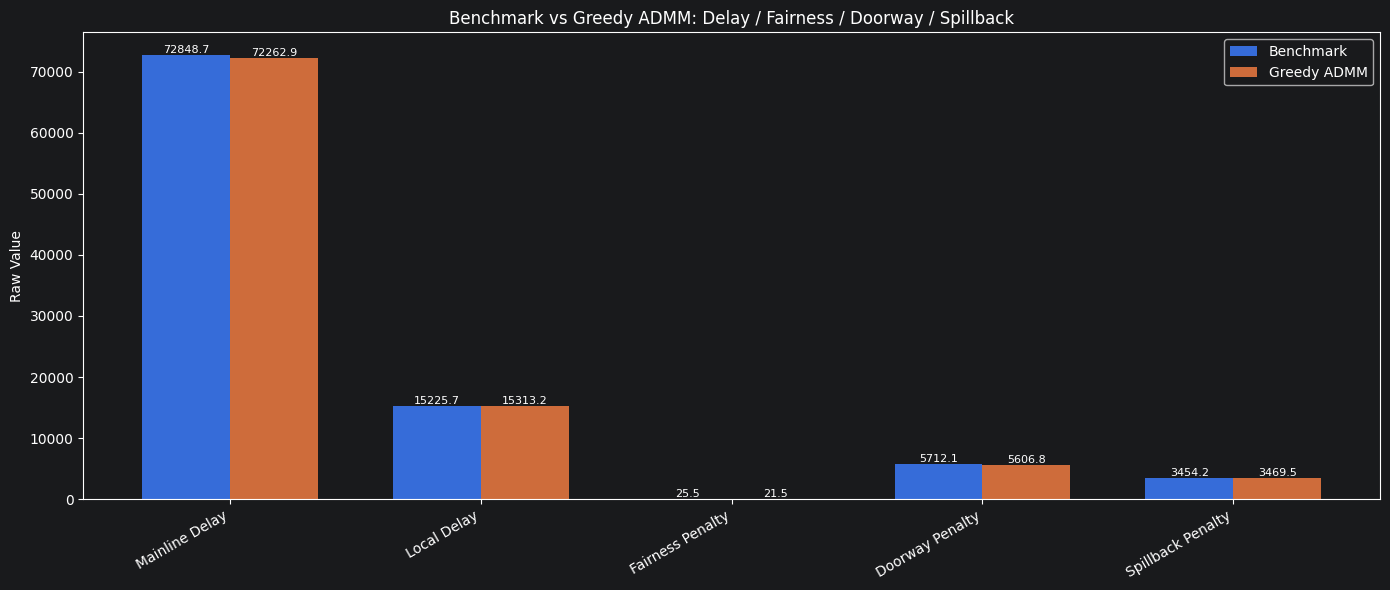

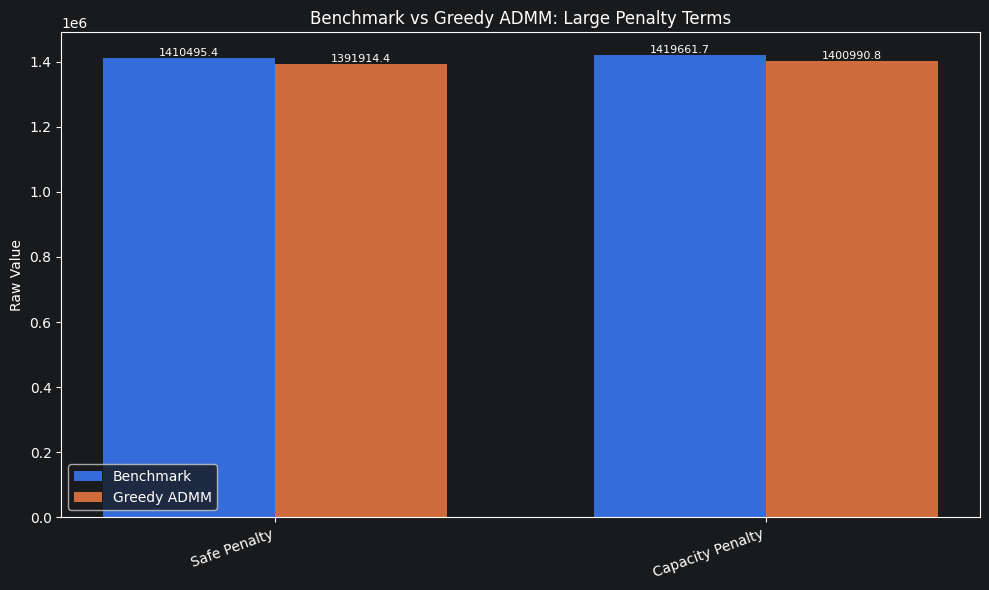

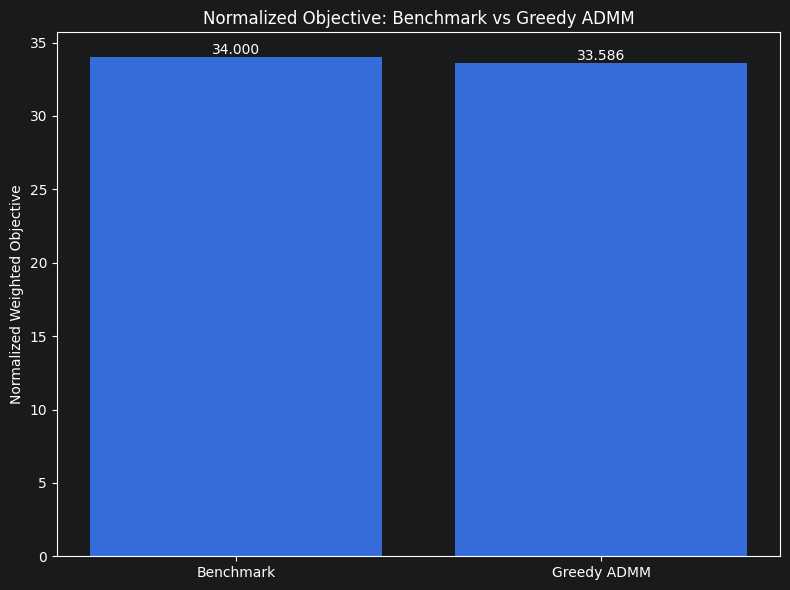

Benchmark terms:
Mainline Delay = 72848.691
Local Delay = 15225.654
Fairness Penalty = 25.453
Doorway Penalty = 5712.108
Safe Penalty = 1410495.372
Physical Penalty = 0.0
Spillback Penalty = 3454.202
Capacity Penalty = 1419661.681
Normalized Objective = 34.0

Greedy ADMM terms:
Mainline Delay = 72262.865
Local Delay = 15313.189
Fairness Penalty = 21.49
Doorway Penalty = 5606.782
Safe Penalty = 1391914.424
Physical Penalty = 0.0
Spillback Penalty = 3469.546
Capacity Penalty = 1400990.752
Normalized Objective = 33.586

Normalized weighted objective:
Benchmark = 34.0
Greedy ADMM = 33.586003
Percent change = -1.218 %

Total system delay:
Benchmark = 88074.345
Greedy ADMM = 87576.054
Percent change = -0.566 %


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Benchmark vs Greedy ADMM plots

# Benchmark totals
before_data = {
    "Mainline Delay": official_totals["mainline_delay"],
    "Local Delay": official_totals["local_delay"],
    "Fairness Penalty": official_totals["fairness_penalty"],
    "Doorway Penalty": official_totals["doorway_penalty"],
    "Safe Penalty": official_totals["safe_penalty"],
    "Physical Penalty": official_totals["physical_penalty"],
    "Spillback Penalty": official_totals["spillback_penalty"],
}

before_data["Capacity Penalty"] = (
    before_data["Doorway Penalty"]
    + before_data["Safe Penalty"]
    + before_data["Physical Penalty"]
    + before_data["Spillback Penalty"]
)

# Greedy ADMM totals
after_data = {
    "Mainline Delay": sum(admm_history_120["mainline_delay"]),
    "Local Delay": sum(admm_history_120["local_delay"]),
    "Fairness Penalty": sum(admm_history_120["fairness_penalty"]),
    "Doorway Penalty": sum(admm_history_120["doorway_penalty"]),
    "Safe Penalty": sum(admm_history_120["safe_penalty"]),
    "Physical Penalty": sum(admm_history_120["physical_penalty"]),
    "Spillback Penalty": sum(admm_history_120["spillback_penalty"]),
}

after_data["Capacity Penalty"] = (
    after_data["Doorway Penalty"]
    + after_data["Safe Penalty"]
    + after_data["Physical Penalty"]
    + after_data["Spillback Penalty"]
)

# Normalized weighted objective

before_total_objective = (
    alpha_main * before_data["Mainline Delay"] / benchmark_denominators_clean["mainline_delay"]
    + beta_local * before_data["Local Delay"] / benchmark_denominators_clean["local_delay"]
    + before_data["Fairness Penalty"] / benchmark_denominators_clean["fairness_penalty"]
    + before_data["Doorway Penalty"] / benchmark_denominators_clean["doorway_penalty"]
    + before_data["Safe Penalty"] / benchmark_denominators_clean["safe_penalty"]
    + before_data["Spillback Penalty"] / benchmark_denominators_clean["spillback_penalty"]
)

after_total_objective = (
    alpha_main * after_data["Mainline Delay"] / benchmark_denominators_clean["mainline_delay"]
    + beta_local * after_data["Local Delay"] / benchmark_denominators_clean["local_delay"]
    + after_data["Fairness Penalty"] / benchmark_denominators_clean["fairness_penalty"]
    + after_data["Doorway Penalty"] / benchmark_denominators_clean["doorway_penalty"]
    + after_data["Safe Penalty"] / benchmark_denominators_clean["safe_penalty"]
    + after_data["Spillback Penalty"] / benchmark_denominators_clean["spillback_penalty"]
)

before_data["Normalized Objective"] = before_total_objective
after_data["Normalized Objective"] = after_total_objective



# Plot 1: smaller-scale terms


labels_small = [
    "Mainline Delay",
    "Local Delay",
    "Fairness Penalty",
    "Doorway Penalty",
    "Spillback Penalty",
]

before_small = [before_data[label] for label in labels_small]
after_small = [after_data[label] for label in labels_small]

x = np.arange(len(labels_small))
width = 0.35

plt.figure(figsize=(14, 6))

bars_before = plt.bar(x - width / 2, before_small, width, label="Benchmark")
bars_after = plt.bar(x + width / 2, after_small, width, label="Greedy ADMM")

plt.title("Benchmark vs Greedy ADMM: Delay / Fairness / Doorway / Spillback")
plt.ylabel("Raw Value")
plt.xticks(x, labels_small, rotation=30, ha="right")
plt.legend()

for bar in bars_before:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

for bar in bars_after:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()



# Plot 2: large-scale terms


labels_big = [
    "Safe Penalty",
    "Capacity Penalty",
]

before_big = [before_data[label] for label in labels_big]
after_big = [after_data[label] for label in labels_big]

x = np.arange(len(labels_big))

plt.figure(figsize=(10, 6))

bars_before = plt.bar(x - width / 2, before_big, width, label="Benchmark")
bars_after = plt.bar(x + width / 2, after_big, width, label="Greedy ADMM")

plt.title("Benchmark vs Greedy ADMM: Large Penalty Terms")
plt.ylabel("Raw Value")
plt.xticks(x, labels_big, rotation=20, ha="right")
plt.legend()

for bar in bars_before:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

for bar in bars_after:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()



# Plot 3: normalized weighted objective


labels = ["Benchmark", "Greedy ADMM"]
values = [before_total_objective, after_total_objective]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values)

plt.ylabel("Normalized Weighted Objective")
plt.title("Normalized Objective: Benchmark vs Greedy ADMM")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()



# Print comparison summary

print("Benchmark terms:")
for key, value in before_data.items():
    print(key, "=", round(value, 3))

print("\nGreedy ADMM terms:")
for key, value in after_data.items():
    print(key, "=", round(value, 3))

print("\nNormalized weighted objective:")
print("Benchmark =", round(before_total_objective, 6))
print("Greedy ADMM =", round(after_total_objective, 6))
print(
    "Percent change =",
    round(
        100 * (after_total_objective - before_total_objective)
        / before_total_objective,
        3,
    ),
    "%"
)

print("\nTotal system delay:")
before_delay = before_data["Mainline Delay"] + before_data["Local Delay"]
after_delay = after_data["Mainline Delay"] + after_data["Local Delay"]

print("Benchmark =", round(before_delay, 3))
print("Greedy ADMM =", round(after_delay, 3))
print(
    "Percent change =",
    round(100 * (after_delay - before_delay) / before_delay, 3),
    "%"
)

In [25]:
# Greedy ADMM sensitivity experiment
# Tests different meter-capacity multipliers and ADMM iteration settings.



meter_capacity_multipliers = [1.0, 1.1, 1.2, 1.5, 2.0]

iteration_settings = [
    {"min_admm_iters": 20, "max_admm_iters": 150},
    {"min_admm_iters": 50, "max_admm_iters": 150},
    {"min_admm_iters": 100, "max_admm_iters": 150},
    {"min_admm_iters": 150, "max_admm_iters": 150},
]

greedy_experiment_results = []
greedy_experiment_histories = {}

for meter_multiplier in meter_capacity_multipliers:

    for iter_setting in iteration_settings:

        min_iters = iter_setting["min_admm_iters"]
        max_iters = iter_setting["max_admm_iters"]

        print(
            "\nRunning Greedy ADMM | meter multiplier =",
            meter_multiplier,
            "| min iters =",
            min_iters,
            "| max iters =",
            max_iters
        )


        # Modified simulation loop with meter-capacity multiplier
        x_current = mainline_initial_state.copy()
        ramp_queue_current = ramp_queue_0.copy()

        history_test = {
            "x": [],
            "R": [],
            "u_apply": [],
            "observed_release": [],
            "ramp_arrival": [],
            "q_in": [],
            "q_out": [],
            "actual_f_out": [],
            "spillback": [],
            "mainline_delay": [],
            "local_delay": [],
            "fairness_penalty": [],
            "doorway_penalty": [],
            "safe_penalty": [],
            "physical_penalty": [],
            "spillback_penalty": [],
            "total_objective": [],
            "admm_iterations": [],
            "final_primal_residual": [],
            "final_dual_residual": [],
        }

        for t in range(num_steps):

            observed_release_t = {
                ramp: float(observed_release_series[ramp][t])
                for ramp in ramp_ids
            }

            ramp_arrival_t = {
                ramp: float(ramp_arrival_series[ramp][t])
                for ramp in ramp_ids
            }

            q_in_boundary_t = float(q_in_boundary_series[t])
            f_out_requested_t = f_out_series[t]

            #
            # Experiment variable:
            # meter capacity = multiplier * observed release
            meter_capacity_t = {
                ramp: meter_multiplier * observed_release_t[ramp]
                for ramp in ramp_ids
            }

            result_t = solve_one_step_admm(
                current_mainline_state=x_current,
                ramp_queue_now=ramp_queue_current,
                ramp_arrival=ramp_arrival_t,
                observed_release=observed_release_t,
                meter_capacity=meter_capacity_t,
                q_in_boundary=q_in_boundary_t,
                f_out_requested=f_out_requested_t,
                doorway_capacity=doorway_capacity,
                physical_capacity=physical_capacity,
                safe_threshold_capacity=safe_threshold_capacity,
                tt_ff_min=tt_ff_min,
                ramp_name_map=ramp_name_map,
                ramp_max_queue_named=ramp_max_queue_named,
                delta_t=delta_t,
                gamma=gamma,
                lambda_1=lambda_1,
                lambda_2=lambda_2,
                lambda_3=lambda_3,
                lambda_4=lambda_4,
                benchmark_denominators=benchmark_denominators_clean,
                alpha_main=alpha_main,
                beta_local=beta_local,
                rho=0.2,
                min_admm_iters=min_iters,
                max_admm_iters=max_iters,
                tol_primal=1e-3,
                tol_dual=1e-2,
            )

            history_test["x"].append(x_current.copy())
            history_test["R"].append(ramp_queue_current.copy())
            history_test["u_apply"].append(result_t["u_opt"].copy())
            history_test["observed_release"].append(observed_release_t.copy())
            history_test["ramp_arrival"].append(ramp_arrival_t.copy())
            history_test["q_in"].append(result_t["q_in"].copy())
            history_test["q_out"].append(result_t["q_out"].copy())
            history_test["actual_f_out"].append(result_t["actual_f_out"].copy())
            history_test["spillback"].append(result_t["spillback_by_ramp"].copy())
            history_test["mainline_delay"].append(result_t["total_mainline_delay"])
            history_test["local_delay"].append(result_t["total_local_delay"])
            history_test["fairness_penalty"].append(result_t["fairness_penalty"])
            history_test["doorway_penalty"].append(result_t["doorway_penalty"])
            history_test["safe_penalty"].append(result_t["safe_penalty"])
            history_test["physical_penalty"].append(result_t["physical_penalty"])
            history_test["spillback_penalty"].append(result_t["spillback_penalty"])
            history_test["total_objective"].append(result_t["total_objective"])
            history_test["admm_iterations"].append(result_t["admm_iterations"])
            history_test["final_primal_residual"].append(result_t["final_primal_residual"])
            history_test["final_dual_residual"].append(result_t["final_dual_residual"])

            x_current = result_t["x_next"].copy()
            ramp_queue_current = result_t["ramp_next"].copy()

        history_test["x_final"] = x_current.copy()
        history_test["R_final"] = ramp_queue_current.copy()

        # Compute totals

        test_totals = {
            "mainline_delay": sum(history_test["mainline_delay"]),
            "local_delay": sum(history_test["local_delay"]),
            "fairness_penalty": sum(history_test["fairness_penalty"]),
            "doorway_penalty": sum(history_test["doorway_penalty"]),
            "safe_penalty": sum(history_test["safe_penalty"]),
            "physical_penalty": sum(history_test["physical_penalty"]),
            "spillback_penalty": sum(history_test["spillback_penalty"]),
        }

        test_totals["capacity_penalty"] = (
            test_totals["doorway_penalty"]
            + test_totals["safe_penalty"]
            + test_totals["physical_penalty"]
            + test_totals["spillback_penalty"]
        )

        test_totals["raw_objective"] = (
            test_totals["mainline_delay"]
            + test_totals["local_delay"]
            + test_totals["fairness_penalty"]
            + test_totals["capacity_penalty"]
        )

        test_normalized_objective = (
            alpha_main * test_totals["mainline_delay"] / benchmark_denominators_clean["mainline_delay"]
            + beta_local * test_totals["local_delay"] / benchmark_denominators_clean["local_delay"]
            + test_totals["fairness_penalty"] / benchmark_denominators_clean["fairness_penalty"]
            + test_totals["doorway_penalty"] / benchmark_denominators_clean["doorway_penalty"]
            + test_totals["safe_penalty"] / benchmark_denominators_clean["safe_penalty"]
            + test_totals["spillback_penalty"] / benchmark_denominators_clean["spillback_penalty"]
        )

        test_system_delay = (
            test_totals["mainline_delay"]
            + test_totals["local_delay"]
        )

        benchmark_system_delay = (
            official_totals["mainline_delay"]
            + official_totals["local_delay"]
        )

        benchmark_objective = 34.0

        objective_change_pct = (
            100
            * (test_normalized_objective - benchmark_objective)
            / benchmark_objective
        )

        delay_change_pct = (
            100
            * (test_system_delay - benchmark_system_delay)
            / benchmark_system_delay
        )

        avg_iters = np.mean(history_test["admm_iterations"])
        max_iter_used = max(history_test["admm_iterations"])

        max_primal = max(history_test["final_primal_residual"])
        max_dual = max(history_test["final_dual_residual"])

        # Save result row

        result_row = {
            "meter_multiplier": meter_multiplier,
            "min_admm_iters": min_iters,
            "max_admm_iters": max_iters,
            "normalized_objective": test_normalized_objective,
            "objective_change_pct": objective_change_pct,
            "system_delay": test_system_delay,
            "delay_change_pct": delay_change_pct,
            "mainline_delay": test_totals["mainline_delay"],
            "local_delay": test_totals["local_delay"],
            "spillback_penalty": test_totals["spillback_penalty"],
            "safe_penalty": test_totals["safe_penalty"],
            "avg_iters": avg_iters,
            "max_iter_used": max_iter_used,
            "max_primal_residual": max_primal,
            "max_dual_residual": max_dual,
        }

        greedy_experiment_results.append(result_row)

        greedy_experiment_histories[
            (meter_multiplier, min_iters, max_iters)
        ] = history_test

        print(
            "Objective =",
            round(test_normalized_objective, 6),
            "| Objective change =",
            round(objective_change_pct, 3),
            "%",
            "| Delay change =",
            round(delay_change_pct, 3),
            "%"
        )


# Display experiment results

greedy_experiment_df = pd.DataFrame(greedy_experiment_results)

display(
    greedy_experiment_df.sort_values(
        by="normalized_objective",
        ascending=True
    ).round(6)
)


Running Greedy ADMM | meter multiplier = 1.0 | min iters = 20 | max iters = 150
Objective = 33.586003 | Objective change = -1.218 % | Delay change = -0.566 %

Running Greedy ADMM | meter multiplier = 1.0 | min iters = 50 | max iters = 150
Objective = 33.129079 | Objective change = -2.562 % | Delay change = -1.219 %

Running Greedy ADMM | meter multiplier = 1.0 | min iters = 100 | max iters = 150
Objective = 32.577984 | Objective change = -4.182 % | Delay change = -2.088 %

Running Greedy ADMM | meter multiplier = 1.0 | min iters = 150 | max iters = 150
Objective = 32.205923 | Objective change = -5.277 % | Delay change = -2.709 %

Running Greedy ADMM | meter multiplier = 1.1 | min iters = 20 | max iters = 150
Objective = 37.667966 | Objective change = 10.788 % | Delay change = 10.518 %

Running Greedy ADMM | meter multiplier = 1.1 | min iters = 50 | max iters = 150
Objective = 37.255329 | Objective change = 9.574 % | Delay change = 10.027 %

Running Greedy ADMM | meter multiplier = 1.1

,meter_multiplier,min_admm_iters,max_admm_iters,normalized_objective,objective_change_pct,system_delay,delay_change_pct,mainline_delay,local_delay,spillback_penalty,safe_penalty,avg_iters,max_iter_used,max_primal_residual,max_dual_residual
3,1.0,150,150,32.205923,-5.276697,85688.209169,-2.709229,70066.963825,15621.245344,3540.081151,1.299937e+06,150.0,150,0.000029,0.003330
2,1.0,100,150,32.577984,-4.182401,86235.554297,-2.087771,70700.796465,15534.757832,3521.172089,1.332902e+06,100.0,100,0.000034,0.003863
1,1.0,50,150,33.129079,-2.561532,87000.777521,-1.218933,71586.702991,15414.074530,3492.845642,1.368676e+06,50.0,50,0.000040,0.004525
0,1.0,20,150,33.586003,-1.217639,87576.053612,-0.565762,72262.865082,15313.188530,3469.546191,1.391914e+06,20.0,20,0.000044,0.005002
7,1.1,150,150,36.452231,7.212445,95819.618769,8.794018,80204.556371,15615.062398,2256.220677,1.595646e+06,150.0,150,0.000029,0.003327
6,1.1,100,150,36.768496,8.142636,96272.541566,9.308269,80743.136787,15529.404780,2244.253712,1.604525e+06,100.0,100,0.000034,0.003860
5,1.1,50,150,37.255329,9.574496,96905.795447,10.027268,81496.042959,15409.752488,2227.507176,1.616700e+06,50.0,50,0.000040,0.004535
4,1.1,20,150,37.667966,10.788135,97337.917397,10.517901,82026.521226,15311.396172,2215.813748,1.623926e+06,20.0,20,0.000044,0.007255
11,1.2,150,150,40.696786,19.696428,106242.873352,20.628627,90634.839891,15608.033461,1262.986847,1.913626e+06,150.0,150,0.000029,0.003326
10,1.2,100,150,40.978047,20.523667,106625.231745,21.062759,91101.612106,15523.619639,1256.568404,1.924187e+06,100.0,100,0.000034,0.003858
